# Разработка алгоритма расчета состояния прибытия пожарных подразделений к зданиям

In [1]:
import numpy as np
import networkx as nx
import pandas as pd
import geopandas as gpd
import osmnx as ox


from genesis.core import BestPointsBase, MetricBase, StateBase
from genesis.best_points import BestNodeHillClimbing
from genesis.states import FirstArrivalUnitState
from genesis.metrics import ArrivalTime, CoverIndex
from genesis.mclp import BestNodesKoptG
from genesis.tools import list_dict_concat
from genesis.utils import timing, Progressbar
import matplotlib.pyplot as plt
from genesis.swiss_knife import CMAP_GrGldRd
from genesis.swiss_knife import MSF, DELAY_TIME

# from fire_units.metrics import Demand


In [2]:
# Загрузка графа, полигона границ и зданий
G = ox.load_graphml("tests/data/test_rng.ml")
area = gpd.read_file("tests/data/test_polygon.gpkg")
buildings = gpd.read_file("tests/data/buildings.gpkg", layer="здания")
# buildings.head()

## Разработка

In [3]:
nodes_gdf = ox.project_gdf(ox.graph_to_gdfs(G, edges=False))
nodes_gdf['node'] = nodes_gdf.index
buildings = ox.project_gdf(buildings)

In [4]:
buildings_new = buildings.sjoin_nearest(nodes_gdf[['geometry']], max_distance=100)
buildings_new.rename(columns={'index_right': 'node'}, inplace=True)
buildings_new.head(2)

,osmid,name,amenity,building,addr:street,addr:housenumber,building:levels,building:flats,demand,geometry,node
0,114435873,NaN,NaN,Многоквартирный жилой дом,улица Ленинского Комсомола,2,9,NaN,0.014152,"POLYGON ((521283.901 6220143.312, 521291.376 6...",9085465307
1,114435874,NaN,NaN,Торговое здание,улица Ленинского Комсомола,NaN,NaN,NaN,0.003726,"POLYGON ((521066.656 6219874.938, 521059.407 6...",9085465281


C:\Users\obsid\AppData\Local\Temp\ipykernel_10096\1152995964.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


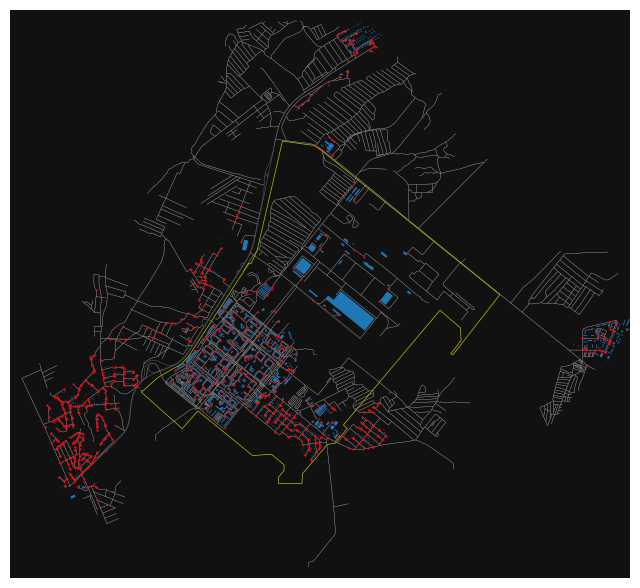

In [5]:
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False)
nodes_gdf2 = ox.graph_to_gdfs(G, edges=False)
nodes_gdf2.loc[buildings_new['node']].plot(ax=ax, c='r', markersize=0.2)
ox.project_gdf(buildings, to_latlong=True).plot(ax=ax)
area.boundary.plot(ax=ax, linewidth=0.5, color='y')
fig.show()

#### Черновики (потом удалить)

In [ ]:
# class FireDemandSatisfyState(FirstArrivalUnitState):
#     def __init__(self, state_algorithm=MSF, weight='travel_time', delay=DELAY_TIME, **kwargs):
#         super().__init__(state_algorithm, weight, delay, **kwargs)

#     def __call__(self,
#                  env: nx.MultiDiGraph,
#                  points: dict,
#                  buildings: gpd.GeoDataFrame,
#                  buildings_node_id_field: str = 'node',
#                  buildings_demand_field: str = 'demand',
#                  area=None,
#                  **kwargs):

#         # print(1, points)

#         # Вот это будет вызывать базовый алгоритм:
#         times, nearest = super().__call__(env, points, area, **kwargs)
#         arrival_state = pd.concat([times, nearest], axis=1)

#         # print(2, len(arrival_state))

#         # здесь сопоставляем building и times
#         merged_df = pd.merge(buildings, arrival_state, left_on=buildings_node_id_field, right_index=True)  # здесь подумать! #, how='left')

#         # Расчет собственно состояния удовлетворенности спроса
#         return merged_df[buildings_demand_field] / merged_df['times'], merged_df['nearest']   #, merged_df['times']

        

# nodes_list = list(G.nodes())
# points = {
#     nodes_list[100]: 'A',
#     nodes_list[2000]: 'B',
# }

# ns = ox.graph_to_gdfs(G, edges=False)
# points_mask = ns.within(area.iloc[0].geometry)

# fu_state = FireDemandSatisfyState()


# # times, nearest = 
# demand_satisfy_state, nearest = fu_state(G,
#                                                 points,
#                                                 buildings_new,
#                                                 # buildings_demand_field='Спрос',
#                                                 # area = points_mask,
#                                                 )
# print(len(demand_satisfy_state))
# # demand_satisfy_state
# # demand_satisfy_state.columns

# demand_satisfy_state, nearest = fu_state(G,             #, times
#                                                 points,
#                                                 buildings_new,
#                                                 # buildings_demand_field='Спрос',
#                                                 area = points_mask,
#                                                 )
# print(len(demand_satisfy_state))

In [7]:
# print('Удовлетворенность спроса', ArrivalTime()(demand_satisfy_state))
# # print('Среднее время прибытия', ArrivalTime()(times))
# # print('Максимальное время прибытия', ArrivalTime(np.max)(times))

Удовлетворенность спроса 0.0013567405525830272


In [ ]:
# # State 1
# points = {
#     nodes_list[1000]: 'A',
#     nodes_list[3000]: 'B',
# }
# demand_satisfy_state1, nearest = fu_state(G, points, buildings_new)
# print('Удовлетворенность спроса', Demand()(demand_satisfy_state1))
# # print('Среднее время прибытия', ArrivalTime()(times))
# print('='*80)

# # State 2
# points = {
#     nodes_list[2000]: 'A',
#     nodes_list[3000]: 'B',
#     nodes_list[4000]: 'C',
# }
# demand_satisfy_state2, nearest = fu_state(G, points, buildings_new)
# print('Удовлетворенность спроса', Demand()(demand_satisfy_state2))
# # print('Среднее время прибытия', ArrivalTime()(times))
# print('='*80)

# # State 3
# points = {
#     nodes_list[2000]: 'A',
#     nodes_list[3000]: 'B',
#     nodes_list[4000]: 'C',
#     nodes_list[5000]: 'D',
# }
# demand_satisfy_state3, nearest = fu_state(G, points, buildings_new)
# print('Удовлетворенность спроса', Demand()(demand_satisfy_state3))
# # print('Среднее время прибытия', ArrivalTime()(times))
# print('='*80)


In [ ]:
# demand_satisfy_state1_metric = Demand()(demand_satisfy_state1)
# demand_satisfy_state2_metric = Demand()(demand_satisfy_state2)
# demand_satisfy_state3_metric = Demand()(demand_satisfy_state3)

# print(demand_satisfy_state1_metric, demand_satisfy_state2_metric, demand_satisfy_state3_metric)

# print(Demand().compare(demand_satisfy_state1_metric, demand_satisfy_state2_metric))
# print(Demand().compare(demand_satisfy_state1_metric, demand_satisfy_state3_metric))
# print(Demand().compare(demand_satisfy_state2_metric, demand_satisfy_state3_metric))

In [6]:
# class Demand(MetricBase):
#     '''
#     Класс-функция расчета метрики удовлетворенности спроса на услуги пожарной охраны
#     '''
#     def __init__(self,
#                  buildings,
#                  f=np.mean,
#                  comp_func:callable=max,
#                  zero_val=0,
#                  buildings_node_id_field: str = 'node',
#                  buildings_demand_field: str = 'demand',
#                  ) -> None:
#         '''
#         `f`: function
#             Функция расчета показателя. По-умолчанию = np.mean,
#             т.е. вычисляется среднее время следования.
#         `comp_func`: callable
#             Функция сравнения значений метрики.
#             По умолчанию - лучшей считается большая.
#         `zero_val`: float = 0
#             Значение которое будет возвращено в случае передачи набора данных `route_times` без элементов.
#         '''
#         self.buildings = buildings
#         self.f = f
#         self.zero_val = zero_val
#         self.buildings_node_id_field = buildings_node_id_field
#         self.buildings_demand_field = buildings_demand_field
#         super().__init__(comp_func)

#     def __call__(self, state, area=None):
#         if not isinstance(state, (list, pd.Series)):
#             raise TypeError(
#                 f"Аргумент state может быть только типа list или pd.Series"
#                 f" Имеется {type(state)}"
#                 )

#         # Отбор узлов по area (списку узлов которые следует учесть в расчете)
#         if not area is None:
#             if isinstance(state, pd.Series):
#                 state_c = state.loc[area]
#             else:
#                 state_c = [x for x in state if x in area]
#         else:
#             state_c = state

#         if len(state_c)==0:
#             return self.zero_val
        
#         # Расчет метрики по спросу
#         merged_df = pd.merge(self.buildings,
#                              state_c,
#                              left_on=self.buildings_node_id_field,
#                              right_index=True)

#         # Расчет собственно состояния удовлетворенности спроса
#         return self.f(merged_df[self.buildings_demand_field] / merged_df['times'])  #, merged_df['nearest']   #, merged_df['times']

#         # return self.f(state_c)

# Тесты работы с алгоритмами BN, MCLP и LSCP

In [5]:
from fire_units.metrics import Demand

## BN

### Monkey

In [7]:
from genesis.best_points import BestNodeMonkey

def global_jump(**kwargs):
    print('Глобальный прыжок')
def local_jump(**kwargs):
    print('Локальный прыжок')

BN = timing(BestNodeMonkey(FirstArrivalUnitState(),
                    Demand(buildings=buildings_new),
                    local_jumps_count=3,
                    after_global_jump_function=global_jump,
                    after_local_jump_function=local_jump))
best_node, best_metric = BN(env=G)
print(best_node, best_metric)

times, nearest = FirstArrivalUnitState()(env=G, points=[best_node])
print(ArrivalTime()(times), CoverIndex()(times), CoverIndex(20)(times))

Глобальный прыжок
Локальный прыжок
Локальный прыжок
Локальный прыжок
Локальный прыжок
Глобальный прыжок
Локальный прыжок
Локальный прыжок
Локальный прыжок
Локальный прыжок
Глобальный прыжок
Локальный прыжок
Локальный прыжок
Локальный прыжок
Локальный прыжок
ВРЕМЯ: 42.35 сек
1577701962 0.0009515276360106618
8.575933005878841 63.15406976744186 99.20058139534883


C:\Users\obsid\AppData\Local\Temp\ipykernel_5832\1486653179.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


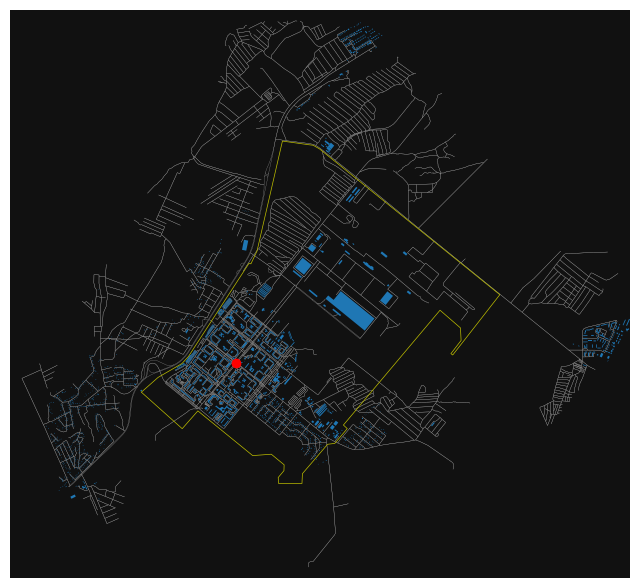

In [8]:
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False)
ox.graph_to_gdfs(G, edges=False).loc[[best_node]].plot(ax=ax, c='r')
ox.project_gdf(buildings, to_latlong=True).plot(ax=ax)
area.boundary.plot(ax=ax, linewidth=0.5, color='y')
fig.show()

### Hill climber

In [9]:
def node_calc(**kwargs):
    print(kwargs, end='\r')

BN = timing(BestNodeHillClimbing(FirstArrivalUnitState(),
                    Demand(buildings=buildings_new),
                    node_calc_end_function=node_calc,
                    ))
best_node, best_metric = BN(env=G)
print(best_node, best_metric)

times, nearest = FirstArrivalUnitState()(env=G, points=[best_node])
print(ArrivalTime()(times), CoverIndex()(times), CoverIndex(20)(times))

ВРЕМЯ: 9.48 сек26923837, 'best_metric': 0.000903158188358116}3}}
426923837 0.000903158188358116
8.506199948427117 63.971656976744185 99.38226744186046


C:\Users\obsid\AppData\Local\Temp\ipykernel_5832\1486653179.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


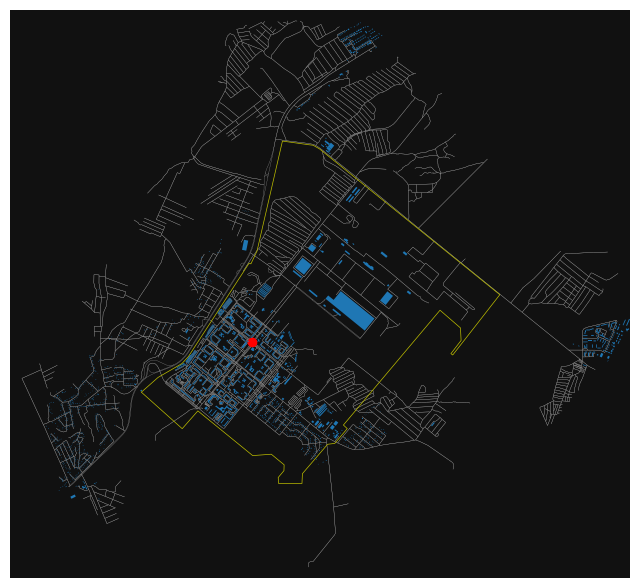

In [10]:
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False)
ox.graph_to_gdfs(G, edges=False).loc[[best_node]].plot(ax=ax, c='r')
ox.project_gdf(buildings, to_latlong=True).plot(ax=ax)
area.boundary.plot(ax=ax, linewidth=0.5, color='y')
fig.show()

### Полный перебор

In [ ]:
from genesis.best_points import BestNodesFull


pb = Progressbar(maxval=G.number_of_nodes(), bins=40)

BN = timing(BestNodesFull(FirstArrivalUnitState(),
                    Demand(buildings = buildings_new),
                    node_calc_end_function = pb,
                    ))
best_node, best_metric = BN(env=G)
print(best_node, best_metric)

times, nearest = FirstArrivalUnitState()(env=G, points=best_node)
print(ArrivalTime()(times), CoverIndex()(times), CoverIndex(20)(times))

8.575933005878841 63.15406976744186 99.20058139534883


C:\Users\obsid\AppData\Local\Temp\ipykernel_15252\957001515.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


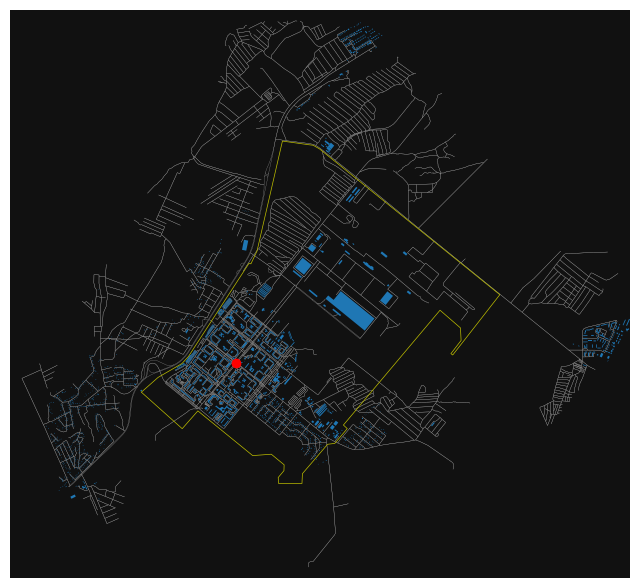

In [10]:
print(ArrivalTime()(times), CoverIndex()(times), CoverIndex(20)(times))

fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False)
ox.graph_to_gdfs(G, edges=False).loc[best_node].plot(ax=ax, c='r')
ox.project_gdf(buildings, to_latlong=True).plot(ax=ax)
area.boundary.plot(ax=ax, linewidth=0.5, color='y')
fig.show()

Обезьяний алгоритм нашел более точное решение!

## MCLP

### ГА

In [13]:
from genesis.mclp import BestNodesGA

def epoch_end_function(epoch, best_metric, cur_metric, **kwargs):
    print(f'Эпоха: {epoch} |', f'Лучшая метрика: {best_metric} |', f'Текущая метрика: {cur_metric} |')

mclp = timing(BestNodesGA(FirstArrivalUnitState(),
                    Demand(buildings = buildings_new),
                    population_size = 50,
                    elite_size = 20,
                    epochs = 30,
                    epoch_end_function = epoch_end_function,
                    ))

nodes = list(G.nodes())
new_units = {
    nodes[1000]: 'a',
    nodes[2000]: 'b',
    nodes[3000]: 'c',
    nodes[4000]: 'd',
}
print(new_units)

best_nodes, best_metrics = mclp(env=G, dynamic_nodes=new_units)
print(best_nodes, best_metrics)

{2034401706: 'a', 2042076750: 'b', 2760591335: 'c', 4901942432: 'd'}
Эпоха: 0 | Лучшая метрика: 0.0010401721251544884 | Текущая метрика: 0.0010401721251544884 |
Эпоха: 1 | Лучшая метрика: 0.0010559850392333778 | Текущая метрика: 0.0010559850392333778 |
Эпоха: 2 | Лучшая метрика: 0.0011374678663824502 | Текущая метрика: 0.0011374678663824502 |
Эпоха: 3 | Лучшая метрика: 0.0011406173928854438 | Текущая метрика: 0.0011406173928854438 |
Эпоха: 4 | Лучшая метрика: 0.0011406173928854438 | Текущая метрика: 0.0011374678663824502 |
Эпоха: 5 | Лучшая метрика: 0.0011406173928854438 | Текущая метрика: 0.0011374678663824502 |
Эпоха: 6 | Лучшая метрика: 0.001174871230293209 | Текущая метрика: 0.001174871230293209 |
Эпоха: 7 | Лучшая метрика: 0.001174871230293209 | Текущая метрика: 0.001174871230293209 |
Эпоха: 8 | Лучшая метрика: 0.0012984493257700654 | Текущая метрика: 0.0012984493257700654 |
Эпоха: 9 | Лучшая метрика: 0.001343528090806338 | Текущая метрика: 0.001343528090806338 |
Эпоха: 10 | Лучша

6.664120786895245 80.92296511627907 99.52761627906976


C:\Users\obsid\AppData\Local\Temp\ipykernel_10096\1822834666.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


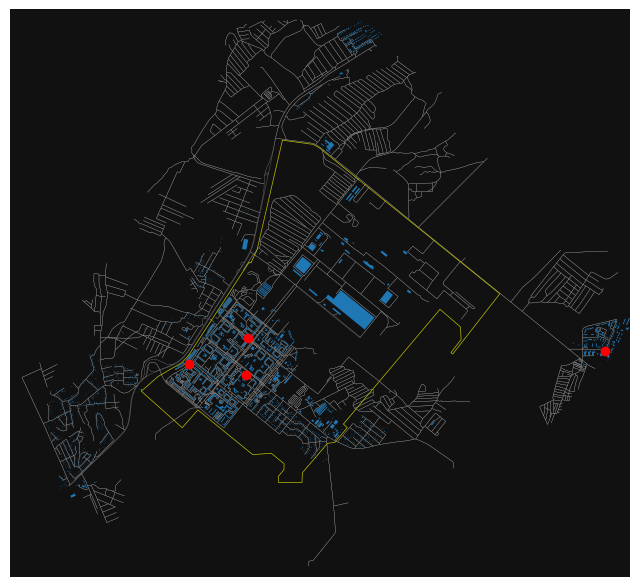

In [15]:
times, nearest = FirstArrivalUnitState()(env=G, points=best_nodes)
print(ArrivalTime()(times), CoverIndex()(times), CoverIndex(20)(times))

fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False)
ox.project_gdf(buildings, to_latlong=True).plot(ax=ax)
area.boundary.plot(ax=ax, linewidth=0.5, color='y')
ox.graph_to_gdfs(G, edges=False).loc[best_nodes.keys()].plot(ax=ax, c='r')
fig.show()

### Генезис

In [11]:
def iter_func(**kwds):
        'Функция вывода хода расчета'
        print(kwds)

class IterFunc:
    def __init__(self):
        self.history = []

    def __call__(self, **kwds):
        'Функция вывода хода расчета'
        self.dynamic_nodes = kwds.get('dynamic_nodes')
        self.static_nodes = kwds.get('static_nodes')
        self.history.append(kwds)
        print(kwds)
# ======================================================================

BNHC = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                       metric_function=Demand(buildings = buildings_new),
                       )

BNG = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=Demand(buildings = buildings_new),
                       best_point_function=BNHC,
                       iterations=5,
                       ))

ifunc = IterFunc()

optimal_nodes, best_metric = BNG(env=G,
    # static_nodes=existed_units,
    dynamic_nodes=new_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=ifunc,
    )
print(optimal_nodes, best_metric)

# ifunc.static_nodes

{'best_metric': 0.0006865915935568695, 'dynamic_nodes': {2034401706: 'a', 2042076750: 'b', 2760591335: 'c', 4901942432: 'd'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 0.00129880189233101, 'dynamic_nodes': {2034401823: 'a', 2005896788: 'b', 1550084436: 'c', 290700398: 'd'}, 'static_nodes': {}}
{'i': 1, 'best_metric': 0.0013390898075515151, 'dynamic_nodes': {868999919: 'a', 2005896788: 'b', 1577701962: 'c', 5116722295: 'd'}, 'static_nodes': {}}
{'i': 2, 'best_metric': 0.0013390898075515151, 'dynamic_nodes': {868999919: 'a', 2005896788: 'b', 1577701962: 'c', 5116722295: 'd'}, 'static_nodes': {}}
{'i': 3, 'best_metric': 0.0013390898075515151, 'dynamic_nodes': {868999919: 'a', 2005896788: 'b', 1577701962: 'c', 5116722295: 'd'}, 'static_nodes': {}}
{'i': 4, 'best_metric': 0.0013390898075515151, 'dynamic_nodes': {868999919: 'a', 2005896788: 'b', 1577701962: 'c', 5116722295: 'd'}, 'static_nodes': {}}
ВРЕМЯ: 13.82 сек
{868999919: 'a', 2005896788: 'b', 1577701962: 'c', 5116722295: 'd'} 0.0013

5.101639235932309 97.03851744186046 100.0


C:\Users\obsid\AppData\Local\Temp\ipykernel_10096\1628015963.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


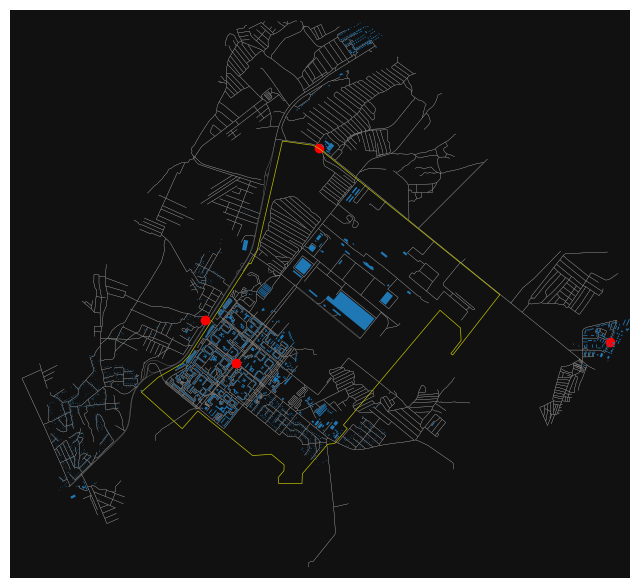

In [12]:
times, nearest = FirstArrivalUnitState()(env=G, points=optimal_nodes)
print(ArrivalTime()(times), CoverIndex()(times), CoverIndex(20)(times))

fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False)
ox.graph_to_gdfs(G, edges=False).loc[optimal_nodes.keys()].plot(ax=ax, c='r')
ox.project_gdf(buildings, to_latlong=True).plot(ax=ax)
area.boundary.plot(ax=ax, linewidth=0.5, color='y')
fig.show()

In [17]:
0.0013761612497996708 / 0.0013390898075515151

1.0276840597539456

Разница на 2%. Выше у ГА.

### ИО

In [6]:
from genesis.mclp import BestNodesSA


def turn_end_function(turn, T, best_metric, cur_metric, **kwargs):
    print(f'Шаг расчета: {turn} |', f'Т: {T}', f'Лучшая метрика: {best_metric} |', f'Текущая метрика: {cur_metric} |')

mclp = timing(BestNodesSA(FirstArrivalUnitState(),
                    Demand(buildings = buildings_new),
                    # end_temperature = 0.001,
                    best_state_find_function = turn_end_function,
                    mutation_max_count=2,
                    ))

nodes = list(G.nodes())
new_units = {
    nodes[1000]: 'a',
    nodes[2000]: 'b',
    nodes[3000]: 'c',
    nodes[4000]: 'd',
}
print(new_units)

best_nodes, best_metrics = mclp(env=G, dynamic_nodes=new_units)
print(best_nodes, best_metrics)

Шаг расчета: None | Т: None Лучшая метрика: None | Текущая метрика: None |
{2034401706: 'a', 2042076750: 'b', 2760591335: 'c', 4901942432: 'd'}
Шаг расчета: 2 | Т: 0.5 Лучшая метрика: 0.0010265823940285095 | Текущая метрика: 0.0010265823940285095 |
Шаг расчета: 8 | Т: 0.125 Лучшая метрика: 0.0010830396844105615 | Текущая метрика: 0.0010830396844105615 |
Шаг расчета: 57 | Т: 0.017543859649122806 Лучшая метрика: 0.0011899734248060443 | Текущая метрика: 0.0011899734248060443 |
Шаг расчета: 829 | Т: 0.0012062726176115801 Лучшая метрика: 0.0012843111133164008 | Текущая метрика: 0.0012843111133164008 |
Шаг расчета: 1207 | Т: 0.0008285004142502071 Лучшая метрика: 0.0013101416590618486 | Текущая метрика: 0.0013101416590618486 |
Шаг расчета: 1571 | Т: 0.0006365372374283895 Лучшая метрика: 0.0013344114720121394 | Текущая метрика: 0.0013344114720121394 |
ВРЕМЯ: 625.54 сек
{9994288455: 'c', 1550086027: 'd', 3981880904: 'b', 2517534299: 'a'} 0.0013344114720121394


6.991415296991796 74.14607558139535 99.38226744186046


C:\Users\obsid\AppData\Local\Temp\ipykernel_4236\1822834666.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


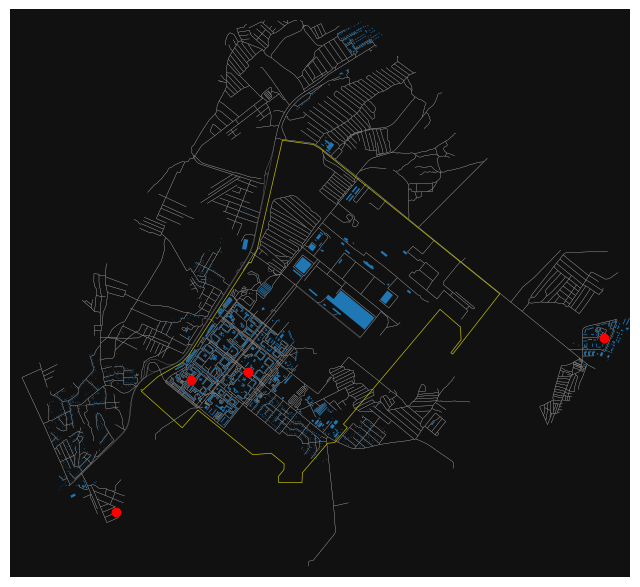

In [9]:
times, nearest = FirstArrivalUnitState()(env=G, points=best_nodes)
print(ArrivalTime()(times), CoverIndex()(times), CoverIndex(20)(times))

fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False)
ox.project_gdf(buildings, to_latlong=True).plot(ax=ax)
area.boundary.plot(ax=ax, linewidth=0.5, color='y')
ox.graph_to_gdfs(G, edges=False).loc[best_nodes.keys()].plot(ax=ax, c='r')
fig.show()

In [8]:
times, nearest = FirstArrivalUnitState()(env=G, points=best_nodes)
Demand(buildings = buildings_new)(times)

0.0013344114720121394